# Assignment 3 – Building an Image Classifier with PyTorch

Rebuilds the *Building an Image Classifier with PyTorch* section of `10_neural_nets_with_pytorch.ipynb` (Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch*, 2025) using scripts generated incrementally by Claude Code, and adds a plot of the training accuracy.

Each code cell below is one generated script from `Claude/assignment3_image_classifier/scripts/`; the markdown cell above it names the script.

### Cell 1 — generated script `scripts/01_setup.py`

Imports, version checks, plotting defaults and device selection.

In [1]:
# Script 01 - Setup: imports, version checks, plotting defaults, device selection
# Based on the "Setup" section of 10_neural_nets_with_pytorch.ipynb (Geron, 2025)
import sys
from packaging.version import Version

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchmetrics

assert sys.version_info >= (3, 10)
# The book asks for PyTorch >= 2.6.0; this code only uses APIs available in 2.x,
# so we warn instead of failing on older installs.
if Version(torch.__version__) < Version("2.6.0"):
    print(f"Note: PyTorch {torch.__version__} is older than the book's 2.6.0")

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("PyTorch:", torch.__version__, "| device:", device)

/opt/anaconda3/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /opt/anaconda3/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Note: PyTorch 2.5.1 is older than the book's 2.6.0
PyTorch: 2.5.1 | device: mps


### Cell 2 — generated script `scripts/02_load_dataset.py`

Download Fashion MNIST with TorchVision; split 55,000 train / 5,000 validation.

In [2]:
# Script 02 - Load Fashion MNIST with TorchVision and split train/validation
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

print(f"train: {len(train_data)}, valid: {len(valid_data)}, "
      f"test: {len(test_data)}")

train: 55000, valid: 5000, test: 10000


### Cell 3 — generated script `scripts/03_dataloaders.py`

Wrap the datasets in DataLoaders and inspect one sample.

In [3]:
# Script 03 - Create DataLoaders and inspect one sample
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# Each entry is a tuple (image, target); images are [channels, rows, columns]
X_sample, y_sample = train_data[0]
print("shape:", X_sample.shape, "| dtype:", X_sample.dtype,
      "| class:", train_and_valid_data.classes[y_sample])

shape: torch.Size([1, 28, 28]) | dtype: torch.float32 | class: Ankle boot


### Cell 4 — generated script `scripts/04_model.py`

Define the two-hidden-layer MLP `ImageClassifier` and the cross-entropy loss.

In [4]:
# Script 04 - Define the MLP image classifier and the loss function
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

print(model)
print("parameters:", sum([param.numel() for param in model.parameters()]))

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
parameters: 266610


### Cell 5 — generated script `scripts/05_train_functions.py`

The book's `evaluate_tm()` and `train2()` training loop.

In [5]:
# Script 05 - Evaluation and training loop (evaluate_tm and train2 from the book)
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

### Cell 6 — generated script `scripts/06_train.py`

Train for 20 epochs with SGD (lr=0.1), keeping the returned `history`.

In [6]:
# Script 06 - Train the classifier with SGD, tracking accuracy with torchmetrics
# The book discards train2's return value (`_ = train2(...)`); we keep it as
# `history` so the training accuracy can be plotted in script 07.
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6061, train metric: 0.7814, valid metric: 0.8402


Epoch 2/20, train loss: 0.4062, train metric: 0.8493, valid metric: 0.8452


Epoch 3/20, train loss: 0.3627, train metric: 0.8665, valid metric: 0.8522


Epoch 4/20, train loss: 0.3351, train metric: 0.8763, valid metric: 0.8626


Epoch 5/20, train loss: 0.3140, train metric: 0.8836, valid metric: 0.8758


...

Epoch 16/20, train loss: 0.2101, train metric: 0.9205, valid metric: 0.8848


Epoch 17/20, train loss: 0.2043, train metric: 0.9225, valid metric: 0.8830


Epoch 18/20, train loss: 0.1986, train metric: 0.9234, valid metric: 0.8876


Epoch 19/20, train loss: 0.1935, train metric: 0.9270, valid metric: 0.8764


Epoch 20/20, train loss: 0.1900, train metric: 0.9276, valid metric: 0.8796


### Cell 7 — generated script `scripts/07_plot_training_accuracy.py`

**New code (not in the book):** plot the training accuracy per epoch.

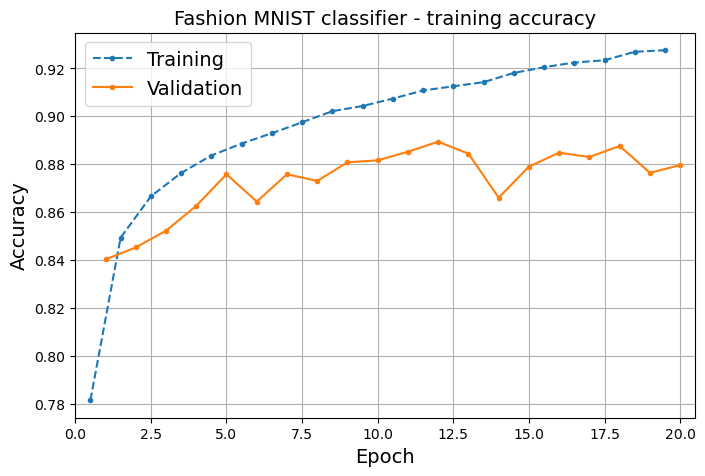

Final training accuracy:   0.9276
Final validation accuracy: 0.8796


In [7]:
# Script 07 - NEW: plot the training accuracy (with validation for reference)
# The training accuracy is averaged over each epoch while the model is still
# learning, so it is plotted half an epoch earlier (same convention as the book).
epochs = np.arange(1, n_epochs + 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs - 0.5, history["train_metrics"], ".--", label="Training")
ax.plot(epochs, history["valid_metrics"], ".-", label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Fashion MNIST classifier - training accuracy")
ax.set_xlim(0, n_epochs + 0.5)
ax.grid()
ax.legend()
plt.show()

print(f"Final training accuracy:   {history['train_metrics'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_metrics'][-1]:.4f}")

### Cell 8 — generated script `scripts/08_predictions.py`

Predict classes and probabilities for three validation images.

In [8]:
# Script 08 - Predict classes and class probabilities for new images
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit

print("predicted:", [train_and_valid_data.classes[index] for index in y_pred])
print("actual:   ", [train_and_valid_data.classes[index] for index in y_new[:3]])

y_proba = F.softmax(y_pred_logits, dim=1).cpu()
print("probabilities:\n", y_proba.round(decimals=3))

y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1).cpu()
print("top-4 probabilities:\n", y_top4_probas.round(decimals=3))
print("top-4 classes:\n", y_top4_indices.cpu())

predicted: ['Sneaker', 'Coat', 'Pullover']
actual:    ['Sneaker', 'Coat', 'Pullover']
probabilities:
 tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8540, 0.0000,
         0.1450],
        [0.0000, 0.0000, 0.0050, 0.0000, 0.9940, 0.0000, 0.0010, 0.0000, 0.0000,
         0.0000],
        [0.0020, 0.0000, 0.6470, 0.0000, 0.1150, 0.0000, 0.2360, 0.0000, 0.0000,
         0.0000]])


top-4 probabilities:
 tensor([[0.8540, 0.1450, 0.0000, 0.0000],
        [0.9940, 0.0050, 0.0010, 0.0000],
        [0.6470, 0.2360, 0.1150, 0.0020]])
top-4 classes:
 tensor([[7, 9, 5, 8],
        [4, 2, 6, 0],
        [2, 6, 4, 0]])


### Cell 9 — generated script `scripts/09_test_accuracy.py`

Evaluate the trained model on the test set.

In [9]:
# Script 09 - Evaluate the trained model on the held-out test set
test_accuracy = evaluate_tm(model, test_loader, accuracy).item()
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.8832
